# Predicting State-wise EV Adoption  
## Notebook 04: EDA

### Purpose
This notebook focuses on the analysis of the dataset to evaluate the relationship between all the features and represent it by visualizing the dataset.

The goal is to find hidden patterns, trends, information,insights, etc. that can come to light with the help of visualization and help understanding the data much more simpler.

In [14]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# reads the dataset and displays the first 5 rows
df = pd.read_csv("../data/ev_adoption_featured.csv")
df.head()

,country,region,year,year_normalized,vehicle_segment,ev_sales(units),petrol_car_sales(units),diesel_car_sales(units),ice_total_sales(units),total_vehicle_sales(units),...,co2_emissions(mt),ev_subsidy(usd),emission_regulation(scale_0-100),ev_growth_rate_yoy(%),ev_growth_rate_category,ev_domination(0/1),economic_index,policy_index,policy_index_lagged_1y,environmental_stringency_ratio
0,Australia,Oceania,2010,0,commercial,5,92877,61921,154798,154803,...,88.7,0,30.4,0.00,Decline,0,4615.5576,0.0,0.0,2.824841
1,Australia,Oceania,2010,0,mass_market,57,535933,73089,609022,609079,...,88.7,0,30.4,0.00,Decline,0,4615.5576,0.0,0.0,2.824841
2,Australia,Oceania,2010,0,premium,37,235282,20462,255744,255781,...,88.7,0,30.4,0.00,Decline,0,4615.5576,0.0,0.0,2.824841
3,Australia,Oceania,2011,1,commercial,11,98092,65395,163487,163498,...,88.3,0,30.8,120.00,Extraordinary Growth,0,4694.5423,0.0,0.0,2.776730
4,Australia,Oceania,2011,1,mass_market,129,569679,77684,647363,647492,...,88.3,0,30.8,126.32,Extraordinary Growth,0,4694.5423,0.0,0.0,2.776730


### 1. Yearly Trend Line Plots

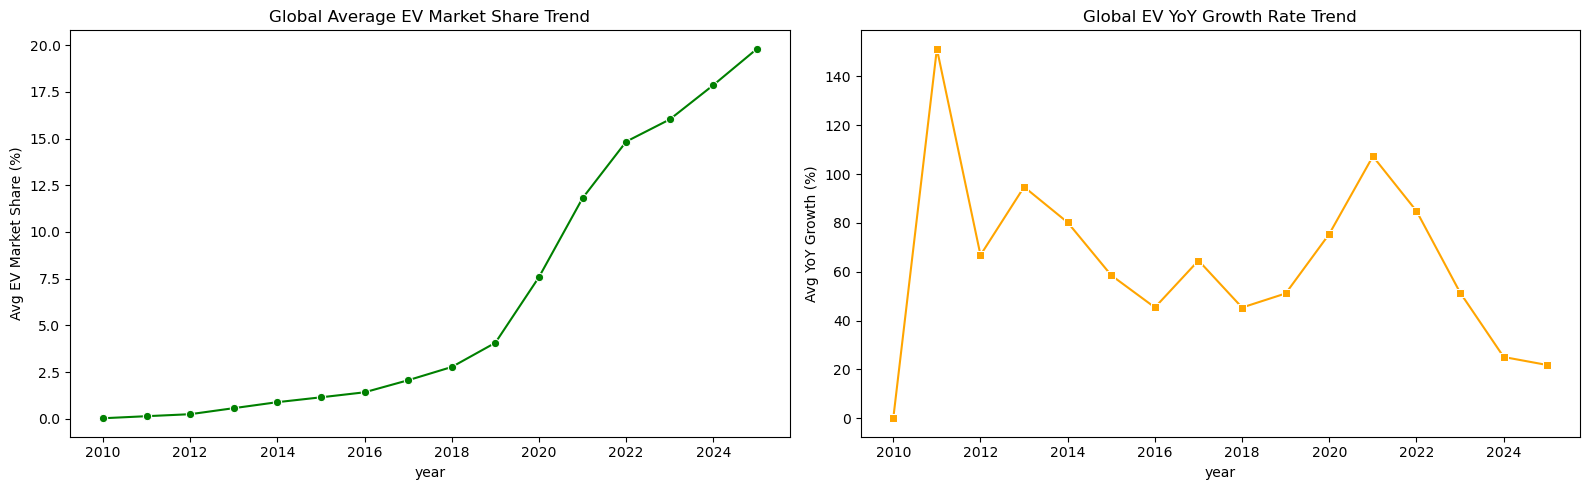

In [ ]:
# Yearly Trends
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# EV Market Share Trend
sns.lineplot(data=df, x='year', y='ev_market_share(%)', estimator='mean', err_style=None, ax=axes[0], marker='o', color='green')
axes[0].set_title('Global Average EV Market Share Trend')
axes[0].set_ylabel('Avg EV Market Share (%)')

# YoY Growth Trend
sns.lineplot(data=df, x='year', y='ev_growth_rate_yoy(%)', estimator='mean', err_style=None, ax=axes[1], marker='s', color='orange')
axes[1].set_title('Global EV YoY Growth Rate Trend')
axes[1].set_ylabel('Avg YoY Growth (%)')

plt.tight_layout()
plt.show()


**Observation: Lineplot (Average)**
- `ev_market_share(%)` shows clear signs of gradual increase over the years, especially picking up after 2019.
- `ev_growth_rate_yoy(%)` is highly volatile with ups and downs but after 2021, there is a steady decline.

### 2. Yearly Trend Line Plot by Region

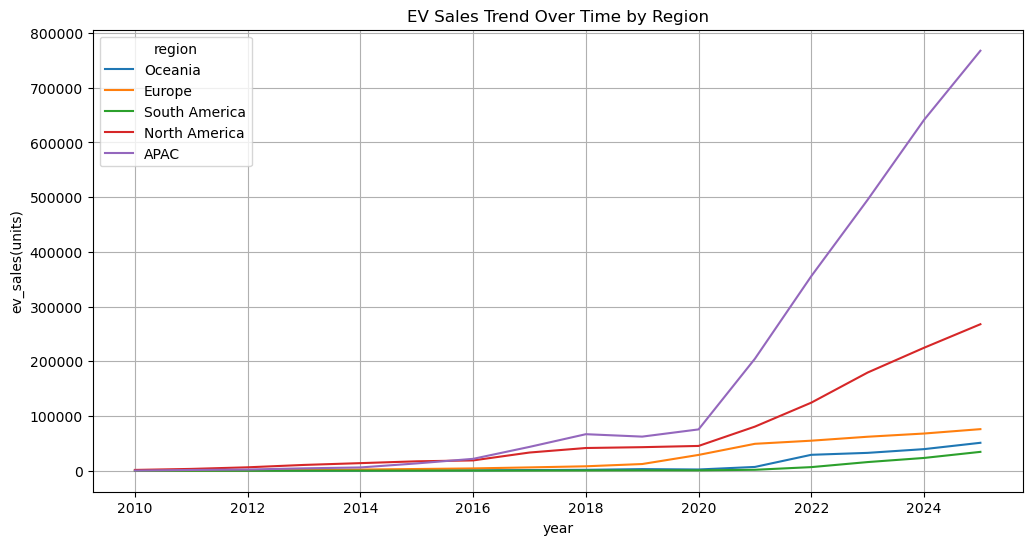

In [ ]:
# Yearly Trends with Regions
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='year', y='ev_sales(units)', hue='region', errorbar=None)
plt.title('EV Sales Trend Over Time by Region')
plt.grid(True)
plt.show()


**Observation: Lineplot (Region)**
- As you can see, significant changes in `ev_sales(units)` took place only after 2020 for most regions.
- **APAC** had an exploding increase in `ev_sales(units)` especially.
- **South America** on the other hand, barely had any increase in `ev_sales(units)`.

### 3. Country-wise Comparison Plots

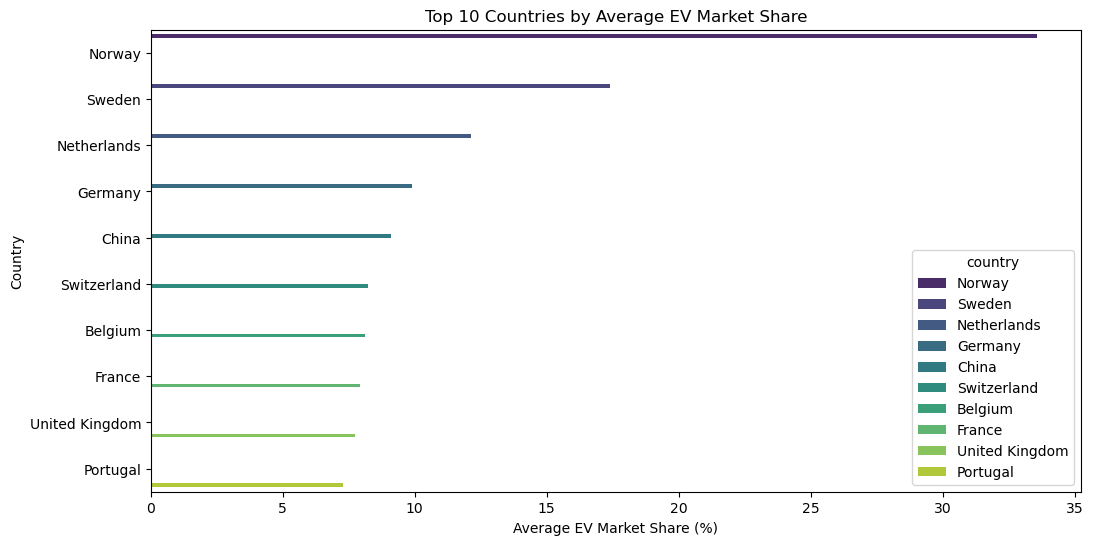

In [5]:
# Top 10 countries by average EV market share
top_countries = df.groupby('country')['ev_market_share(%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, hue=top_countries.index, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Average EV Market Share')
plt.xlabel('Average EV Market Share (%)')
plt.ylabel('Country')
plt.show()


**Observation: Horizontal Bar Plot**
- **Norway** has the most `ev_market_share(%)`, almost double to the second most `ev_market_share(%)` country, **Sweden**.
- The rest of the countries seem to possess between 6%-13% of `ev_market_share(%)`.

### 4. Countplots for Categorical Features

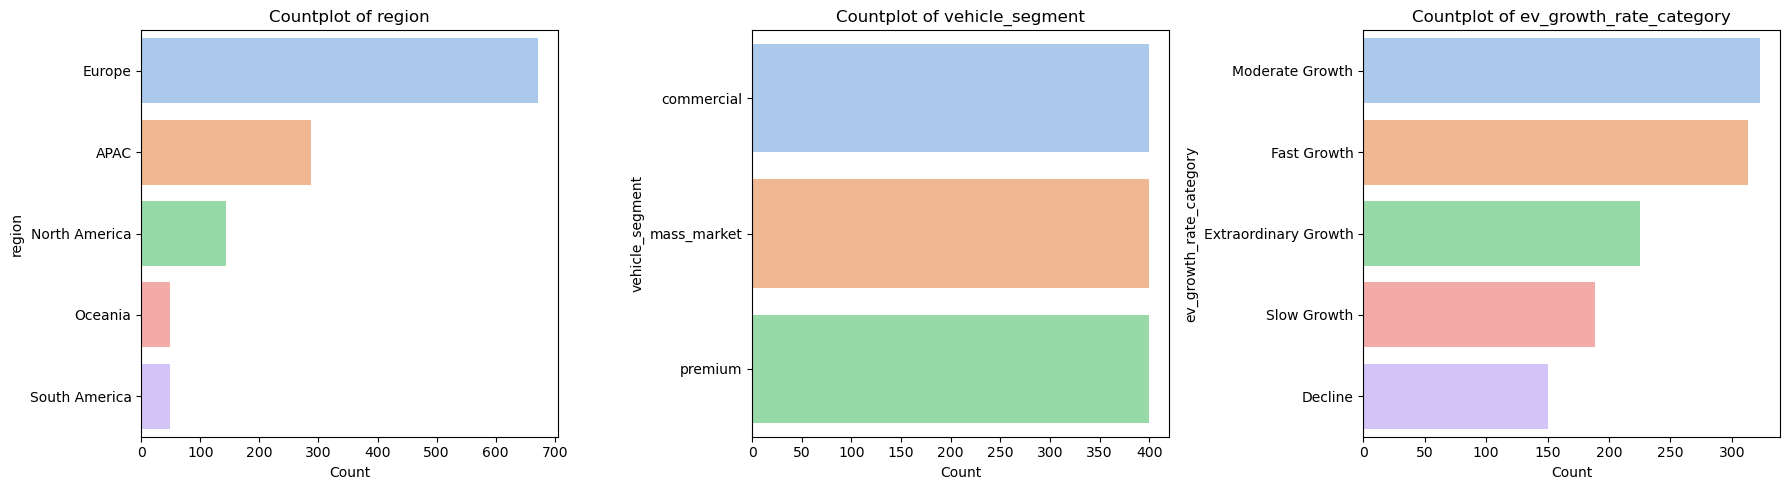

In [6]:
# Countplots for key categorical / discrete features
categorical_cols = ['region', 'vehicle_segment', 'ev_growth_rate_category']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(categorical_cols):
    sns.countplot(y=df[col], ax=axes[i], palette='pastel', order=df[col].value_counts().index)
    axes[i].set_title(f'Countplot of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


**Observation Summary: Countplots**
- In Regions, you can observe there being **Europe** with the maximum number of countries and **South America** with the least number of countries
- In Vehicle Segment, you will observe an abnormally equal representation of bars, this is due to each country being represented into 3 segments, showing that no data is missing.
- In EV Growth Rate Category, **Moderate Growth** and **Fast Growth** seem to be most common, with **Decline** being the least common

### 5. Feature Interaction Plots

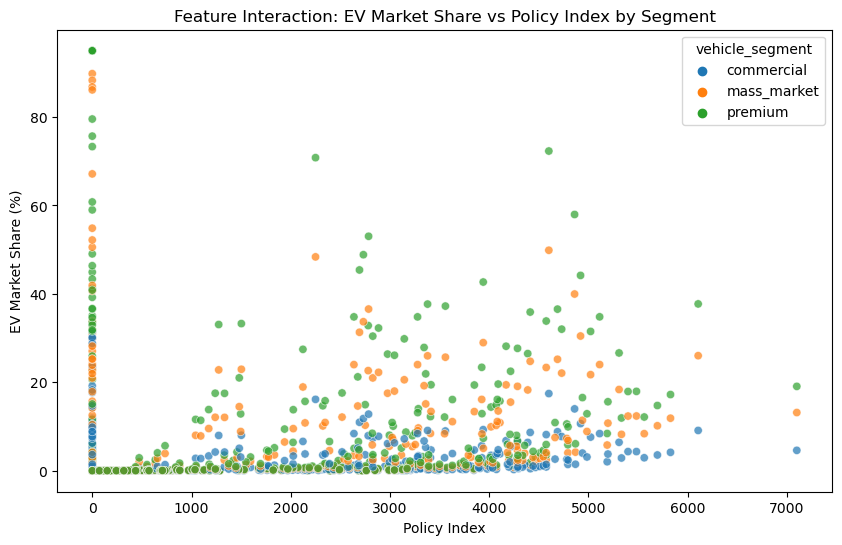

In [7]:
# Interaction: EV Market Share vs Policy Index colored by Vehicle Segment
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='policy_index', y='ev_market_share(%)', hue='vehicle_segment', alpha=0.7)
plt.title('Feature Interaction: EV Market Share vs Policy Index by Segment')
plt.xlabel('Policy Index')
plt.ylabel('EV Market Share (%)')
plt.show()


**Observation: Scatterplot**
- The verticle line indicates that there is no government policy in place to motivate the population to buy EV. However, the population still tends to buy EV without incentives in some Regions.(This effect can also happen if 0 is being used as a placeholder for missing data)
- The scatterplot provides an insight that **premium** car buyers are most responsive to Policies. **Commercial** buyers are laggin behind, expressing that the current policies are not incentivizing for them.
- The scatterplot also shows that a high Policy Index doesn't necessarily mean high EV Market Share. But, it does unlock the potential to high EV Market Share.

### 6. Pairplots for Relationships

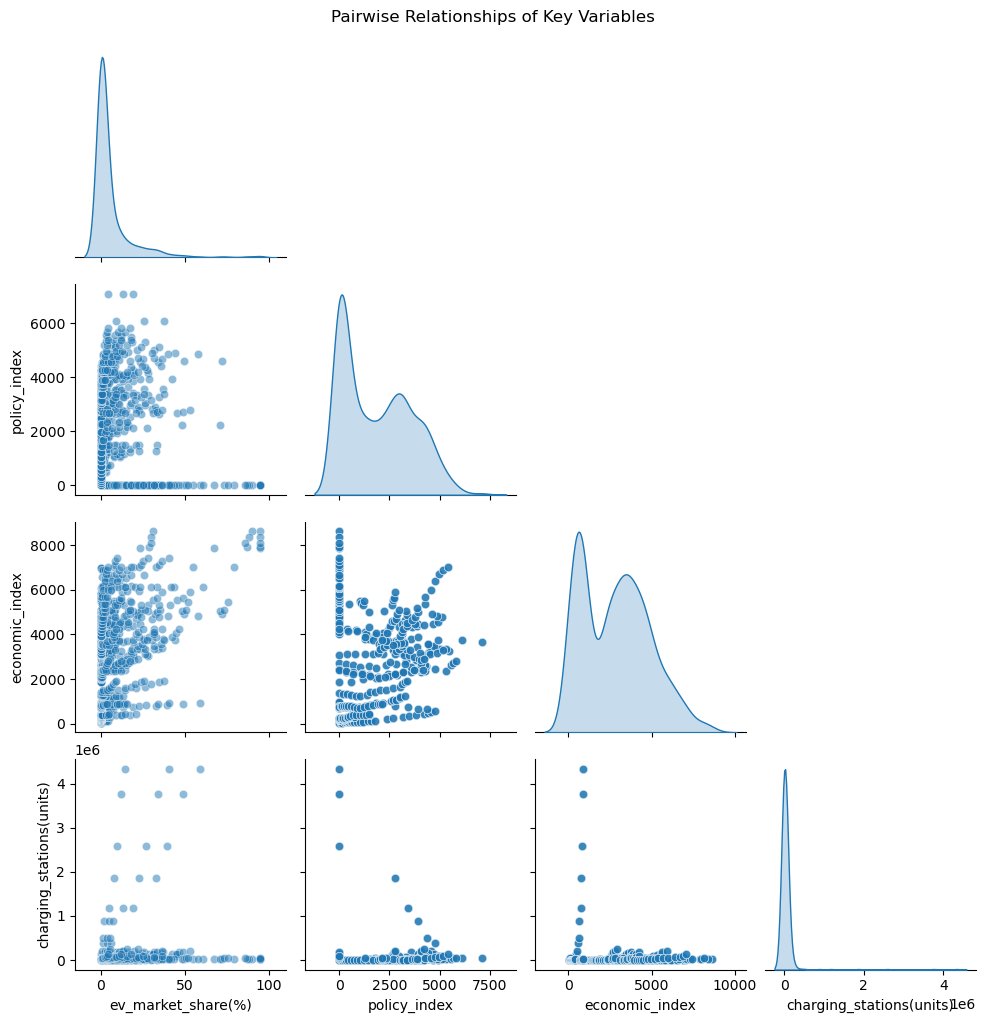

In [8]:
# Pairplot to see bivariate relationships
pairplot_cols = ['ev_market_share(%)', 'policy_index', 'economic_index', 'charging_stations(units)']
sns.pairplot(df[pairplot_cols], diag_kind='kde', corner=True, plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships of Key Variables', y=1.02)
plt.show()


**Observation: Pairplots**
- `ev_market_share` and `charging_stations` are both extremely right-skewed, meaning the features are not uniform, vast majority of the countries/units have near 0 EV adoption with a few outliers present forming the tail.
- In the comparison between `ev_market_share` and `economic_index`, it shows that countries with low economic index tend to have low EV market share, so economic index is important for EV growth.
- In the comparison between `economic_index` and `policy_index`, it is clear that if economic index is high enough, it is more likely that they will create more EV subsidies, therefore, increase policy index.
- All the visualizations in the lower row are mostly flat due to the extreme outliers present(US, China, etc.), therefore, it is required to use logarithmic transformation if we plan on using this feature for prediction.

### 7. Distribution Plots (Histogram & KDE)

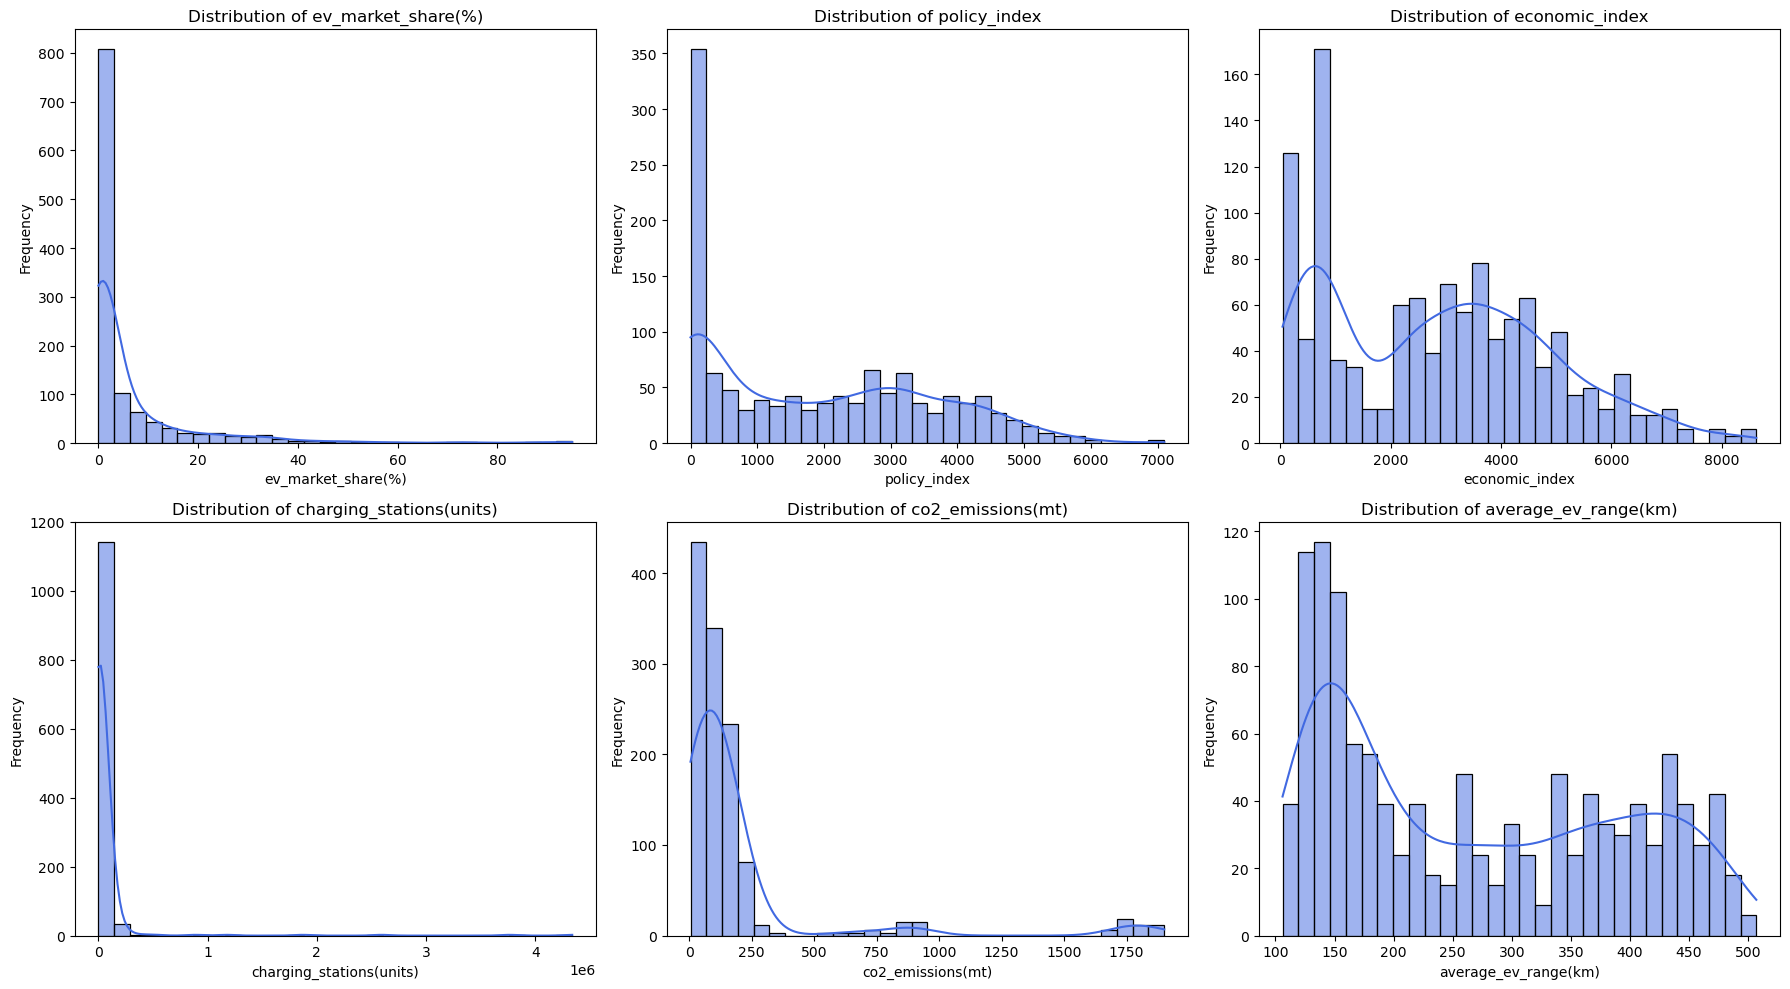

In [9]:
# Plotting distributions for major continuous numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Ensuring df is loaded (just in case the notebook is run out of sequence)
try:
    df
except NameError:
    df = pd.read_csv('../Data/ev_adoption_featured.csv')

numerical_cols = ['ev_market_share(%)', 'policy_index', 'economic_index', 'charging_stations(units)', 'co2_emissions(mt)', 'average_ev_range(km)']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='royalblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


**Observation: Distribution Plots**
- `ev_market_share` is heavily right-skewed, expressing that most countries don't have much of EV adoption
- `policy_index` is also mostly right-skewed, however, there are some countries that try to promote EV adoption more than others. Most put no effort though.
- `economic_index` is right skewed, with a volatile distribution. This shows that the majority of the countries are poor or moderately well off, while a few are rich.
- `charging_stations` is heavily right-skewed, expressing that most countries don't promote EV promotion well enough
- `co2_emmision` is heavily right-skewed, which is good since it shows that most countries are not suffering from pollution by vehicle exhaust yet, but there are some outliers.
- `average_ev_range` is right-skewed, meaning that the milage of EV vehicles should be increased, but the distribution shows that some EV vehicles do have good milage.

### 8. Outlier Detection
We will use boxplots to identify potential outliers in numerical features.


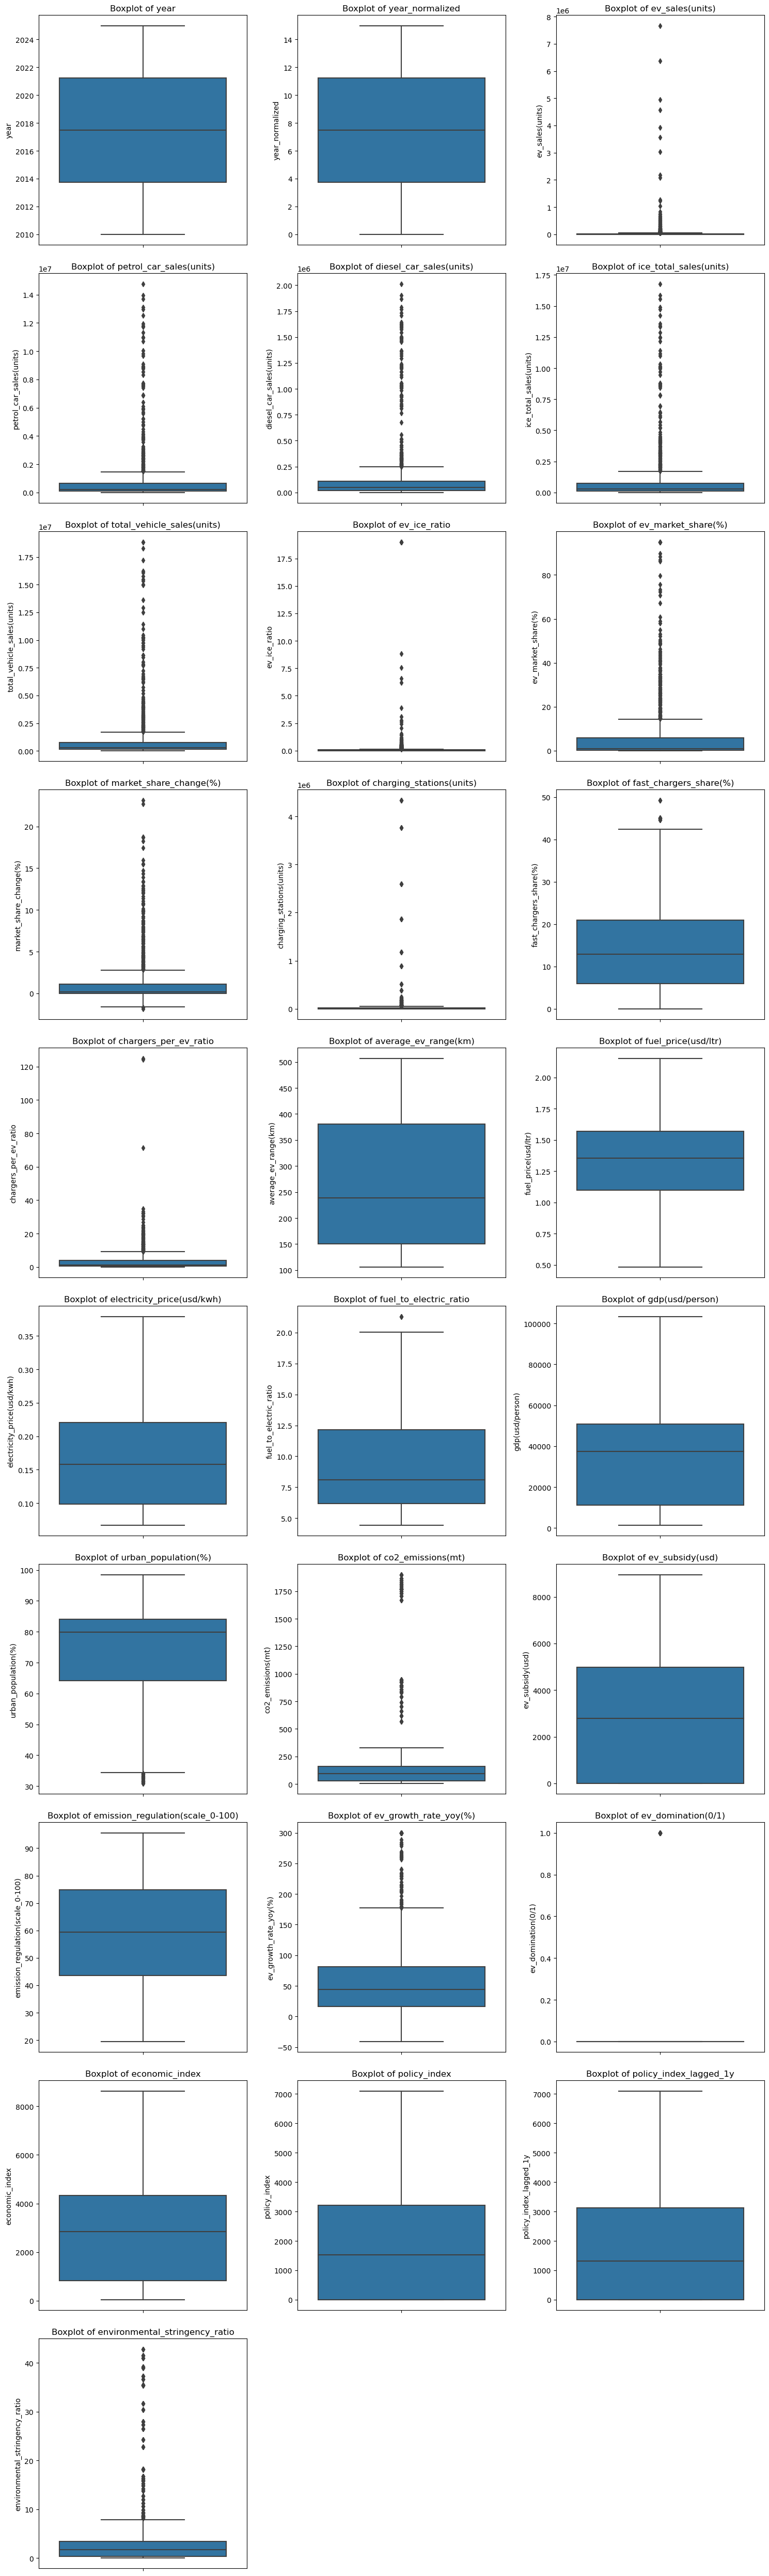

In [15]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

num_plots = len(numeric_columns)
cols = 3
rows = math.ceil(num_plots / cols)

plt.figure(figsize=(15, 5 * rows))
for i, col in enumerate(numeric_columns):
    plt.subplot(rows, cols, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    
plt.tight_layout()
plt.show()


**Observation: Boxplots**
- Some boxplots such as `ev_sales`,`charging_stations` and `co2_emissions` have most features with near 0 values but a few outliers of massive values, causing boxplots to look squished with lots of outliers present
- Some other boxplots such as `urban_population`,`fuel_price`,`gdp` and `average_ev_range` are normally distributed and look balanced.
- This boxplot helps me decide which features to work with in the prediction phase.

### 9. Correlation Analysis
Correlation heatmap helps in identifying highly correlated features and potential multicollinearity.


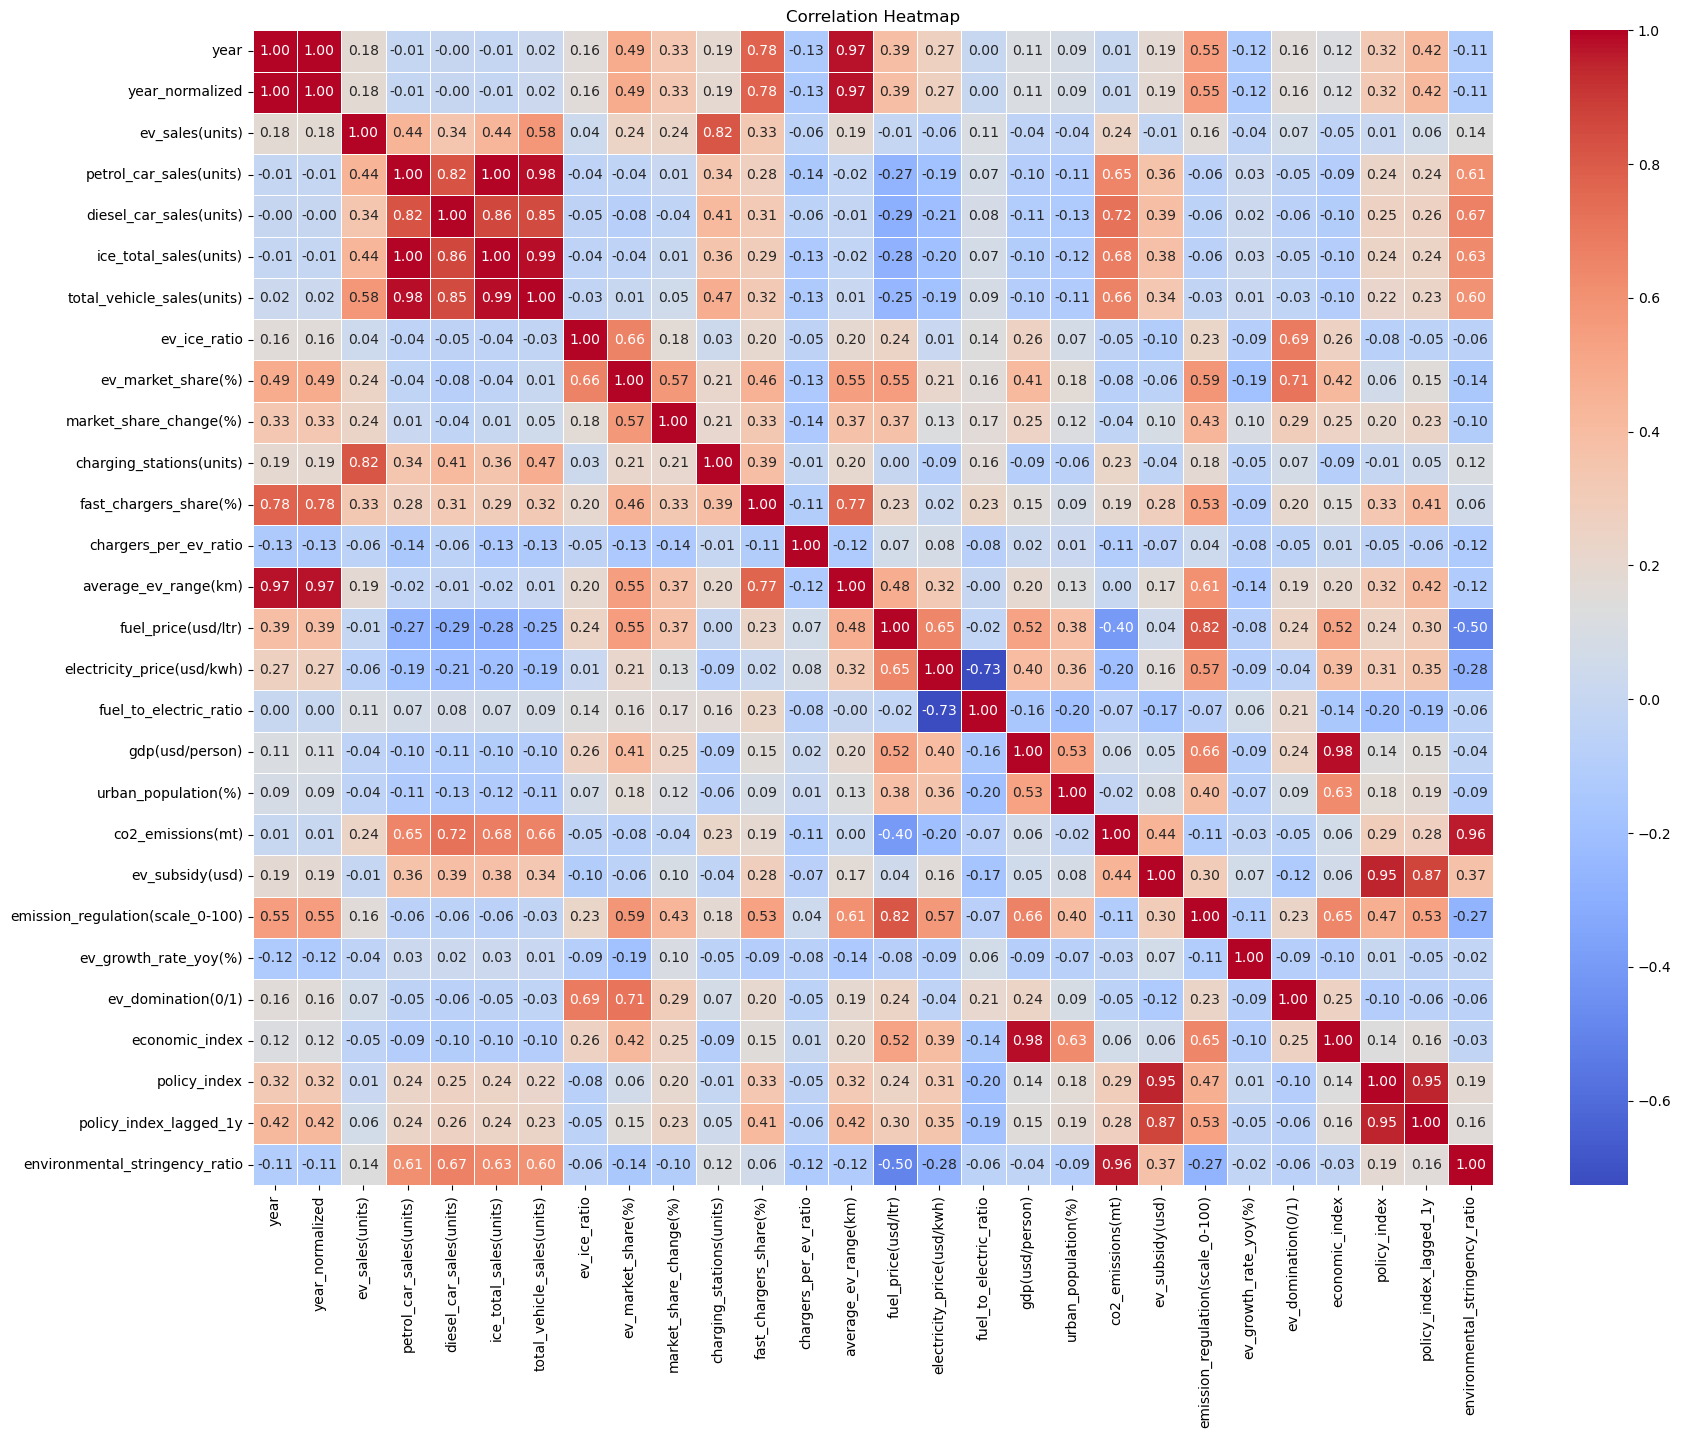

In [11]:
plt.figure(figsize=(20, 15))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


**Observation: Correlation Heatmap**
- Correlation map helps me analyze which features are dangerous to put in the prediction phase, as it would cause overfitting due to multicollinearity.
- The list would be mentioned in Observation Summary.

## Observations Summary

### Data Visualization Insights (Simplified)

**1. What Drives EV Adoption Most?**
- **Government Action (`policy_index` & `policy_index_lagged_1y`)**: High subsidies and strict emission rules force people to buy EVs. Looking at last year's rules also helps predict this year's sales.
- **Wealth & City Living (`economic_index`)**: Rich countries with big cities adopt EVs much faster because they can afford to build charging stations everywhere.
- **Chargers (`charging_stations(units)`)**: More chargers = more EVs sold. It's a direct, undeniable link.
- **Fuel vs Electricity Cost (`fuel_to_electric_ratio`)**: When petrol gets expensive and electricity stays cheap, consumers switch to EVs immediately.

**2. Key Market Trends:**
- **Time (`year_normalized`)**: EV sales are exploding higher every single year.
- **Vehicle Types:** Everyday cars (mass market) and luxury cars (premium) are switching to electric fast. Trucks and vans (commercial) are falling way behind.
- **Data Overload (Multicollinearity):** Many columns tell us the exact same thing (like GDP and Economic Index). We need to throw out the duplicates so our model doesn't get confused.

**3. Problems We Need To Fix:**
- **The "Cheating" Column (Data Leakage):** The `chargers_per_ev_ratio` column mathematically uses "EV Sales" to calculate itself. If we give this column to our model, the model will just cheat and use it to guess EV Market Share instantly. We must delete it.
- **Messy Data (Skewness & Outliers):** China and Europe have wildly more chargers and sales than everyone else. This makes the data extremely lopsided. 

**4. Our Solution (Adding Tree Models):**
- Because our data is so lopsided and messy, simple models (like Linear Regression) will fail. We must use advanced **Tree-Based Models (Random Forest and XGBoost)** which naturally handle messy, lopsided data without breaking a sweat.

### Feature Removal List for Model Building

**1. Data Leakage (MUST DROP)**
Features that directly use future knowledge or are mathematically derived using the target metric (`ev_sales`).
- **`market_share_change(%)`**: Mathematically derived directly from the target.
- **`ev_growth_rate_yoy(%)`**: Directly derived from EV sales over time.
- **`ev_growth_rate_category`**: A binned version of the leaked YoY growth metric.
- **`ev_domination(0/1)`**: A post-outcome flag directly reflecting if EV share bypassed a threshold.
- **`ev_sales(units)`**: Since `Market Share` = `EV Sales / Total Sales`, keeping `ev_sales` gives the model the exact answer.
- **`chargers_per_ev_ratio`**: Its denominator is `ev_sales`. Highly leaky.

**2. Multicollinearity (MUST DROP)**
Variables that contain the exact same redundant information as other columns (Correlation > 0.85). Keeping them in XGBoost won't harm accuracy, but it will randomly scatter and ruin Feature Importance explainability.
- **`ice_total_sales(units)`**: Mathematically dependent on `petrol_car_sales` and `diesel_car_sales`.
- **`total_vehicle_sales(units)`**: A direct summation of EV, Petrol, and Diesel. A perfect collinear trap.
- **`ev_ice_ratio`**: Collinear with base sales numbers.

**3. Base Index Components (MUST DROP)**
To force the model to interpret clean macroeconomic concepts, we drop the raw inputs that make up our engineered indices.
- **`gdp(usd/person)`**: Replaced by `economic_index`.
- **`urban_population(%)`**: Replaced by `economic_index`.
- **`ev_subsidy(usd)`**: Replaced by `policy_index`.
- **`emission_regulation(scale_0-100)`**: Replaced by `policy_index`.
- **`co2_emissions(mt)`**: Replaced by `environmental_stringency_ratio`.

**4. Redundant Variables (MUST DROP)**
- **`year`**: Redundant to `year_normalized`.

## Next Step

Proceed to Notebook 05: Model Building